## DFT Plot

absFreqSpectrum: [[0. 0.]
 [0. 0.]
 [0. 0.]
 ...
 [0. 0.]
 [0. 0.]
 [0. 0.]]
highest amplitude: 16720.0
highest amplitude index: 7602
highest amplitude frequency: 1689.3333333333333


/var/folders/qk/pz9gz5ds2gz27n9rkfdv84_m0000gn/T/ipykernel_16151/1440899622.py:17: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampleFreq, myRecording = scipy.io.wavfile.read("D3.wav")


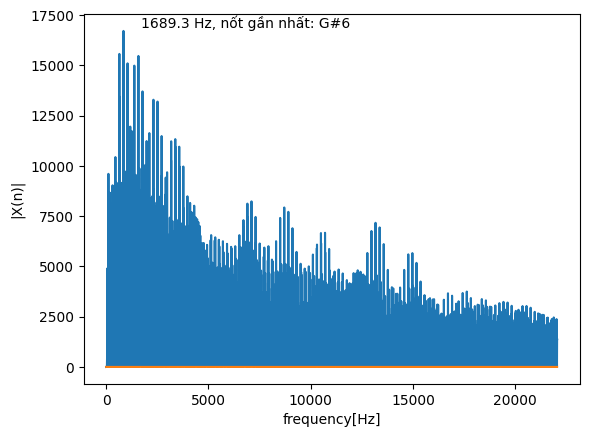

In [12]:
import scipy.io.wavfile
import matplotlib.pyplot as plt
import numpy as np
from scipy.fftpack import fft

CONCERT_PITCH = 440
ALL_NOTES = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]


def find_closest_note(pitch):
    i = int(np.round(np.log2(pitch / CONCERT_PITCH) * 12))
    closest_note = ALL_NOTES[i % 12] + str(4 + (i + 9) // 12)
    closest_pitch = CONCERT_PITCH * 2 ** (i / 12)
    return closest_note, closest_pitch


sampleFreq, myRecording = scipy.io.wavfile.read("D3.wav")

sampleDur = len(myRecording) / sampleFreq
timeX = np.arange(0, sampleFreq / 2, sampleFreq / len(myRecording))
absFreqSpectrum = abs(fft(myRecording))

print("absFreqSpectrum:", absFreqSpectrum)
highest_amplitude = np.max(absFreqSpectrum)
highest_amplitude_index = np.argmax(absFreqSpectrum)
highest_amplitude_frequency = timeX[highest_amplitude_index]
print("highest amplitude:", highest_amplitude)
print("highest amplitude index:", highest_amplitude_index)
print("highest amplitude frequency:", highest_amplitude_frequency)

# Add text label showing peak frequency
plt.text(
    highest_amplitude_frequency,
    highest_amplitude,
    f"{highest_amplitude_frequency:.1f} Hz, nốt gần nhất: {find_closest_note(highest_amplitude_frequency)[0]}",
    horizontalalignment="left",
    verticalalignment="bottom",
)


plt.plot(timeX, absFreqSpectrum[: len(myRecording) // 2])
plt.ylabel("|X(n)|")
plt.xlabel("frequency[Hz]")
plt.show()

## HPS Plot

/var/folders/qk/pz9gz5ds2gz27n9rkfdv84_m0000gn/T/ipykernel_16151/983413826.py:40: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampleFreq, myRecording = scipy.io.wavfile.read("D3#.wav")


Tần số cơ bản phát hiện được: 155.50 Hz
Nốt gần nhất: D#3 (155.56 Hz)
Lệch: -0.71 cents, Hoàn toàn đúng nốt. 🎯


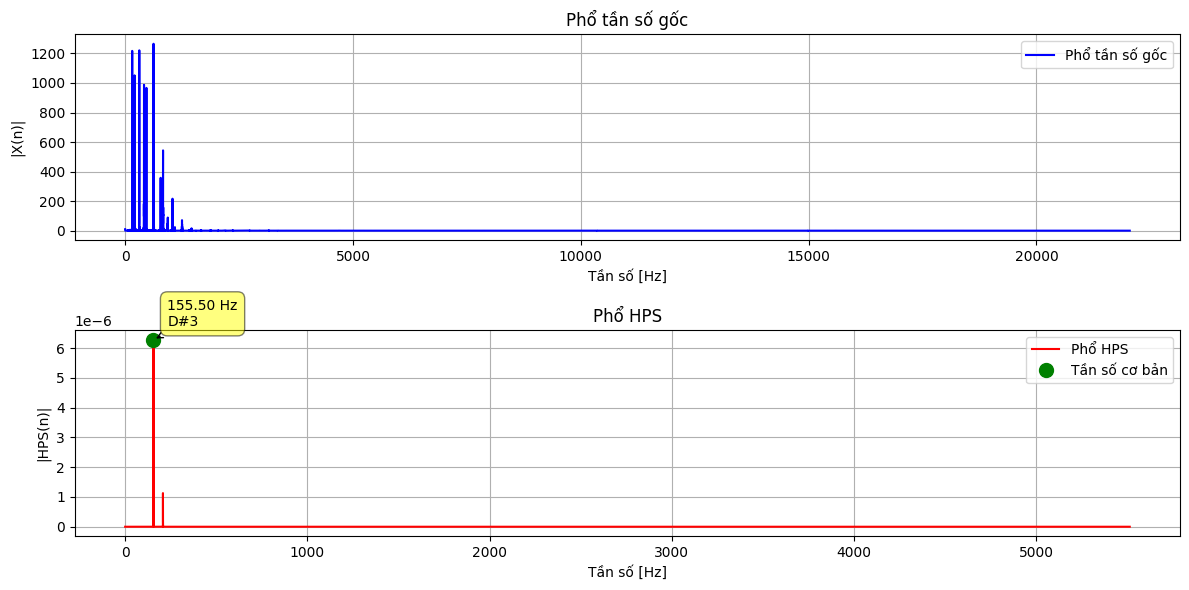

In [ ]:
import scipy.io.wavfile
import matplotlib.pyplot as plt
import numpy as np
from scipy.fftpack import fft
import copy

CONCERT_PITCH = 440
ALL_NOTES = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]
NUM_HPS = 4  # Số lượng hài âm để tính HPS

# Bảng tham chiếu độ lệch cents
CENTS_REFERENCE = {
    (0, 1): "Hoàn toàn đúng nốt. 🎯",
    (1, 5): "Gần như không thể nghe thấy.",
    (5, 20): "Người có tai tốt có thể nhận ra.",
    (20, 50): "Dễ nhận ra, âm nghe bị lệch.",
    (50, 100): "Nghe như một nốt khác. 🎵",
}


def get_cents_description(cents):
    """Trả về mô tả dựa trên độ lệch cents"""
    abs_cents = abs(cents)
    for (lower, upper), description in CENTS_REFERENCE.items():
        if lower <= abs_cents and abs_cents < upper:
            return description
    return CENTS_REFERENCE[(50, 100)]


def find_closest_note(pitch):
    i = int(np.round(np.log2(pitch / CONCERT_PITCH) * 12))
    closest_note = ALL_NOTES[i % 12] + str(4 + (i + 9) // 12)
    closest_pitch = CONCERT_PITCH * 2 ** (i / 12)
    # Calculate cents difference
    cents = 1200 * np.log2(pitch / closest_pitch)
    return closest_note, closest_pitch, cents


# Đọc file âm thanh
sampleFreq, myRecording = scipy.io.wavfile.read("D3#.wav")

# Xử lý stereo/mono
if len(myRecording.shape) > 1:  # Nếu là stereo
    myRecording = myRecording.mean(axis=1)  # Chuyển sang mono bằng cách lấy trung bình

# Chuẩn hóa dữ liệu
myRecording = myRecording.astype(float)
myRecording = myRecording / np.max(np.abs(myRecording))

# Tính thời gian và tần số
sampleDur = len(myRecording) / sampleFreq
timeX = np.arange(0, sampleFreq / 2, sampleFreq / len(myRecording))

# Áp dụng cửa sổ Hanning
window = np.hanning(len(myRecording))
windowed_signal = myRecording * window

# Tính FFT
absFreqSpectrum = abs(fft(windowed_signal))
freqSpectrum = absFreqSpectrum[: len(myRecording) // 2]

# Nội suy phổ tần số
mag_spec_ipol = np.interp(
    np.arange(0, len(freqSpectrum), 1 / NUM_HPS),
    np.arange(0, len(freqSpectrum)),
    freqSpectrum,
)

# Chuẩn hóa phổ
mag_spec_ipol = mag_spec_ipol / np.linalg.norm(mag_spec_ipol, ord=2)

# Tính HPS
hps_spec = copy.deepcopy(mag_spec_ipol)
for i in range(NUM_HPS):
    tmp_hps_spec = np.multiply(
        hps_spec[: int(np.ceil(len(mag_spec_ipol) / (i + 1)))],
        mag_spec_ipol[:: (i + 1)],
    )
    if not any(tmp_hps_spec):
        break
    hps_spec = tmp_hps_spec

# Tìm tần số cơ bản
max_ind = np.argmax(hps_spec)
max_freq = max_ind * (sampleFreq / len(myRecording)) / NUM_HPS


# Tìm nốt gần nhất
closest_note, closest_pitch, cents = find_closest_note(max_freq)

# In kết quả
print(f"Tần số cơ bản phát hiện được: {max_freq:.2f} Hz")
print(f"Nốt gần nhất: {closest_note} ({closest_pitch:.2f} Hz)")
print(f"Lệch: {cents:.1f} cents, {get_cents_description(cents)}")
if abs(cents) > 10:
    if cents > 0:
        print("Cần hạ dây")
    else:
        print("Cần lên dây")


# Vẽ đồ thị
plt.figure(figsize=(12, 6))

# Vẽ phổ tần số gốc
plt.subplot(2, 1, 1)
plt.plot(timeX[: len(freqSpectrum)], freqSpectrum, "b-", label="Phổ tần số gốc")
plt.ylabel("|X(n)|")
plt.xlabel("Tần số [Hz]")
plt.title("Phổ tần số gốc")
plt.grid(True)
plt.legend()

# Vẽ phổ HPS
plt.subplot(2, 1, 2)
hps_freq = np.arange(0, sampleFreq / 2, sampleFreq / (len(myRecording) * NUM_HPS))
hps_freq = hps_freq[: len(hps_spec)]  # Đảm bảo độ dài khớp với hps_spec
plt.plot(hps_freq, hps_spec, "r-", label="Phổ HPS")
plt.plot(max_freq, hps_spec[max_ind], "go", markersize=10, label="Tần số cơ bản")
plt.ylabel("|HPS(n)|")
plt.xlabel("Tần số [Hz]")
plt.title("Phổ HPS")
plt.grid(True)
plt.legend()

# Thêm chú thích cho tần số cơ bản
plt.annotate(
    f"{max_freq:.2f} Hz\n{closest_note}",
    xy=(max_freq, hps_spec[max_ind]),
    xytext=(10, 10),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0"),
)

plt.tight_layout()
plt.show()